# Validation of best model RNN approach

In [30]:
import numpy as np  
import matplotlib.pyplot as plt  
from sklearn.preprocessing import MinMaxScaler  
from sklearn.model_selection import train_test_split 
import torch  
import torch.nn as nn  
import torch.optim as optim 

In [31]:
import nn_fncs
import numpy as np
import scipy.io


mat_data= scipy.io.loadmat('./Data/kinematics_data2.mat', )
data_input = mat_data.get('nn_input')[:,:8]
data_output = mat_data.get('nn_output')
data_input = np.expand_dims(data_input, axis=2)
data_output = np.concatenate((data_output[:,1:9],data_output[:,10:18]), axis=1)
print("Input and output data shapes:")
print(data_input.shape)
print(data_output.shape)


Input and output data shapes:
(500000, 8, 1)
(500000, 16)


In [32]:
def point_distances_from_sample(sample):
    """
    Calculate Euclidean distances between paired (x, y) coordinates in a sample.
    Pairs: (0,8), (1,9), ..., (7,15)
    Args:
        sample (np.ndarray): 1D array with 16 elements, first 8 are x, next 8 are y.
    Returns:
        np.ndarray: Array of distances for each pair.
    """
    x_coords = sample[:8]
    y_coords = sample[8:16]
    distances = np.sqrt((x_coords[1:] - x_coords[:-1])**2 + (y_coords[1:] - y_coords[:-1])**2)  # Distance from origin
    return distances


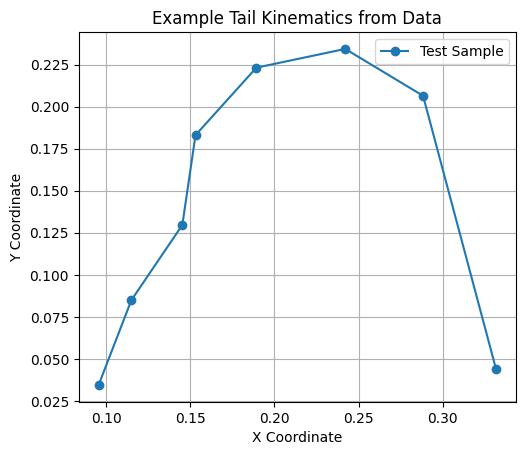

In [33]:
import matplotlib.pyplot as plt
import random

def plot_tail(sample, title="Tail Kinematics", label=None):
    """
    Plot the tail kinematics given a sample of 16 values (8 x-coordinates and 8 y-coordinates).
    Args:
        sample (np.ndarray): 1D array with 16 elements, first 8 are x, next 8 are y.
        title (str): Title of the plot.
    """
    x_coords = sample[:8]
    y_coords = sample[8:16]
    
    plt.plot(x_coords, y_coords, marker='o', label=label)
    plt.legend()
    # plt.xlim(0, 0.6)
    # plt.ylim(-0.4, 0.4)
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.title(title)
    plt.grid()
    plt.gca().set_aspect('equal')


# Example usage
# Randomly select a sample from data_output and plot
random_index = random.randint(0, data_output.shape[0] - 1)
plot_tail(data_output[random_index], title="Example Tail Kinematics from Data", label="Test Sample")



In [34]:
# Dataset preparation

import torch
from torch.utils.data import DataLoader
import torch.nn.functional as F

torch.set_default_dtype(torch.float64)
# Normalize data
# data_input = F.normalize(torch.tensor(data_input, dtype=torch.float64))
# data_output = F.normalize(torch.tensor(data_output, dtype=torch.float64))
# Define dataset split percentages
train_data_percentage = 0.85
valid_data_percentage = 0.1
test_data_percentage = 0.05

train_size = int(len(data_input) * train_data_percentage)
valid_size = int(len(data_input) * valid_data_percentage)
test_size = len(data_input) - train_size - valid_size

valid_index_start = train_size
valid_index_end = train_size + valid_size
test_index_start = valid_index_end
test_index_end = len(data_input) 
#

# Split data into training and validation sets
train_dataset = torch.utils.data.TensorDataset(torch.tensor(data_input[:train_size], dtype=torch.float64), 
                                               torch.tensor(data_output[:train_size], dtype=torch.float64))
valid_dataset = torch.utils.data.TensorDataset(torch.tensor(data_input[valid_index_start:valid_index_end], dtype=torch.float64), 
                                               torch.tensor(data_output[valid_index_start:valid_index_end], dtype=torch.float64))
# valid_dataset_input = torch.tensor(data_input[valid_index_start:valid_index_end], dtype=torch.float64)
# valid_dataset_output = torch.tensor(data_output[valid_index_start:valid_index_end], dtype=torch.float64)
#Test dataset
test_dataset_input = torch.tensor(data_input[test_index_start:test_index_end], dtype=torch.float64)
test_dataset_output = torch.tensor(data_output[test_index_start:test_index_end], dtype=torch.float64)
# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=100, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=100, shuffle=True)

test_dataset_output.dtype

print(f'Train dataset size: {len(train_dataset)}')
print(f'Validation dataset size: {len(valid_dataset)}')
print(f'Test dataset size: {len(test_dataset_input)}')

Train dataset size: 425000
Validation dataset size: 50000
Test dataset size: 25000


In [35]:
print(f'Test dataset input shape: {test_dataset_input.shape}')
print(f'Test dataset output shape: {test_dataset_output.shape}')

Test dataset input shape: torch.Size([25000, 8, 1])
Test dataset output shape: torch.Size([25000, 16])


In [36]:
# MODEL STRUCTURE

import torch
import torch.nn as nn
import torch.nn.functional as F

class TailKinematicsRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=2, num_layers=8, output_size=16):  
        super(TailKinematicsRNN, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(hidden_size*num_layers, output_size)
        
    def forward(self, x):
        
        out, _ = self.rnn(x)
        out = self.flatten(out)
        out = self.fc(out)  # Get the output of the
        
        return out

# Create the model
model = TailKinematicsRNN()

# Print model summary
print(model)

TailKinematicsRNN(
  (rnn): RNN(1, 2, num_layers=8, batch_first=True)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc): Linear(in_features=16, out_features=16, bias=True)
)


In [37]:
# TESTING
import torch
from torcheval.metrics.functional import mean_squared_error, r2_score
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
# Load the best model
import nn_fncs
model = TailKinematicsRNN()
model_path = nn_fncs.best_model_path('./BestModel/', model_name='best_model_rnn')
model.load_state_dict(torch.load('./BestModel/' + model_path))
model = model.to(device)

#evaluate the model
model.eval()
print(f"Using device: {device}")
test_dataset_input = test_dataset_input.to(device)
test_dataset_output = test_dataset_output.to(device)
pred = model(test_dataset_input)
print(f'Test dataset predictions shape: {pred.shape}')
distances = point_distances_from_sample(pred[10].cpu().detach().numpy())
print(distances)
mean_squared_error(pred,test_dataset_output)
print(f'MSE loss on test dataset: {mean_squared_error(pred,test_dataset_output):1.5E}')
print(f'R2 on test dataset: {r2_score(pred, test_dataset_output):1.5E}')


Best model loaded: best_model_rnn_0.9993029281.pt (Accuracy: 0.9993029281%)
Using device: cuda:0
Test dataset predictions shape: torch.Size([25000, 16])
[0.05389228 0.05352362 0.05435121 0.05457427 0.05298876 0.05372476
 0.16914475]
MSE loss on test dataset: 7.19037E-06
R2 on test dataset: 9.99298E-01


torch.Size([25000, 16])
torch.Size([25000, 8, 1])
7948


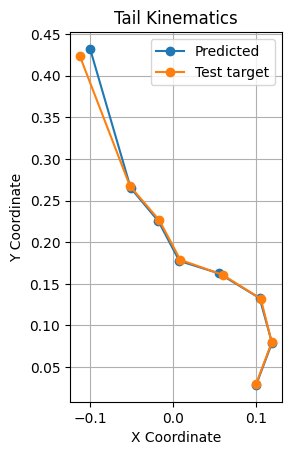

In [38]:
# Visualize random test sample prediction
import matplotlib.pyplot as plt
import random
random_index = random.randint(0, test_dataset_input.shape[0] - 1)
print(pred.shape)
print(test_dataset_input.shape)
print(random_index)
plt.figure()
plot_tail(pred[random_index].cpu().detach().numpy(), label='Predicted')
plot_tail(test_dataset_output[random_index].cpu().detach().numpy(), label="Test target")
plt.grid(True)
plt.show()

In [39]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Number of parameters: {total_params}")

Number of parameters: 366


In [40]:
# Calculate prediction time
import time
model.eval()
data = torch.randn((1,8,1), dtype=torch.float64).to(device)
start_time = time.time()
pred = model(data)
end_time = time.time()
print(f"Prediction time for one sample: {end_time - start_time:1.5E} seconds")




Prediction time for one sample: 3.06249E-03 seconds
